In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector as SFS_sk
from mlxtend.feature_selection import SequentialFeatureSelector as SFS_mlx

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Load Dataset & Inspect

In [4]:
# Importing Dataset
df = pd.read_csv("../DataSets/HousingData.csv")
print(f"Number of features : {len(df.columns)}")
df.sample(5)

Number of features : 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
42,0.14150,0.0,6.91,0.0,0.448,6.169,6.6,5.7209,3,233,17.9,383.37,5.81,25.3
81,0.04462,25.0,4.86,0.0,0.426,6.619,70.4,5.4007,4,281,19.0,395.63,7.22,23.9
126,0.38735,0.0,25.65,0.0,0.581,5.613,NaN,1.7572,2,188,19.1,359.29,27.26,15.7
444,12.80230,0.0,18.10,0.0,0.740,5.854,96.6,1.8956,24,666,20.2,240.52,23.79,10.8
57,0.01432,100.0,1.32,0.0,0.411,6.816,40.5,8.3248,5,256,15.1,392.90,3.95,31.6


In [5]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [6]:
# Missing Value
print(f" Missing Value:\n{df.isna().sum()[df.isna().sum()>0]}")
print(f"Total Number of Missing Values : {df.isnull().sum().sum()}")

 Missing Value:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64
Total Number of Missing Values : 120


**Observation:** Six columns carry 20 missing values each we will use Median imputation as it's robust to the heavy skew in features like `CRIM`, and it's applied before any selection so every subset is evaluated on identical data.

>NOTE: Imputing on the full dataset before cross-validation leaks a small amount of information across folds (the median is computed using rows that later appear in validation folds). The strictly correct approach puts the imputer inside the CV pipeline. The effect here is negligible '20' values per column out of 506 is not a big deal, but it's worth noting.

In [7]:
# For now let's fill the missing values using their median
df = df.fillna(df.median())

feature_name = [name for name in df.columns if name != 'MEDV']
X = df[feature_name].values
y = df['MEDV'].values

print(f"Features : {feature_name}")
print(f"Number of Features : {len(feature_name)}")
print(f"Null Values : {np.isnan(X).sum()}")

Features : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Number of Features : 13
Null Values : 0


In [ ]:
def make_reg():
    return make_pipeline(StandardScaler(), LinearRegression())

kf = KFold(n_splits=4, shuffle=True, random_state=42)

# Splitting the data set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

baseline = make_reg()
baseline.fit(X_train, y_train)

baseline_train_r2 = r2_score(y_train, baseline.predict(X_train))
baseline_test_r2 = r2_score(y_test, baseline.predict(X_test))
baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test)))
baseline_cv = cross_val_score(make_reg(), X, y, cv=kf, scoring='r2')

print(f"Baseline (13 features) : CV R2 : {np.mean(baseline_cv):.4f} +/- {np.std(baseline_cv):.4f}\n")


Baseline (13 features) : CV R2 : 0.7058 +/- 0.0388



## 2. Backward elimination — the whole path in one library call

`mlxtend`'s `SequentialFeatureSelector` with `k_features=(1, 13)` and
`forward=False` doesn't just return one subset — `.subsets_` holds the
best subset (and its CV scores) *at every size along the way*, which is
exactly the full path needed to plot against forward selection's path.
No manual loop required this time.

In [43]:
backward_mlx = SFS_mlx(
    make_reg(), k_features=(1,13), forward=False, floating=False,
    scoring='r2', cv=kf, verbose=0, n_jobs=-1
)

backward_mlx.fit(pd.DataFrame(X, columns=feature_name), y)

backward_rows = []

for k, info in backward_mlx.subsets_.items():
    backward_rows.append({
        "n_features":k,
        "feature":tuple(feature_name[i] for i in info["feature_idx"]),
        "cv_r2_mean":info["avg_score"],
        "cv_r2_std":np.std(info["cv_scores"])
    })
    
backward_df = pd.DataFrame(backward_rows).sort_values(by="n_features", ascending=False)
backward_df

,n_features,feature,cv_r2_mean,cv_r2_std
0,13,"(CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD...",0.705817,0.038752
1,12,"(CRIM, ZN, INDUS, CHAS, NOX, RM, DIS, RAD, TAX...",0.707302,0.037727
2,11,"(CRIM, ZN, CHAS, NOX, RM, DIS, RAD, TAX, PTRAT...",0.708665,0.037284
3,10,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.705813,0.035962
4,9,"(CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, B, LSTAT)",0.702901,0.034655
5,8,"(CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LSTAT)",0.699548,0.034971
6,7,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.698290,0.040346
7,6,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.695225,0.035176
8,5,"(NOX, RM, DIS, PTRATIO, LSTAT)",0.688325,0.030434
9,4,"(RM, DIS, PTRATIO, LSTAT)",0.665680,0.032342


In [35]:
backward_mlx.subsets_.items()

dict_items([(13, {'feature_idx': (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12), 'cv_scores': array([0.68104471, 0.6880878 , 0.77276183, 0.68137566]), 'avg_score': np.float64(0.7058174974312512), 'feature_names': ('CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT')}), (12, {'feature_idx': (0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12), 'cv_scores': array([0.68827485, 0.6878522 , 0.77243546, 0.68064673]), 'avg_score': np.float64(0.7073023089415675), 'feature_names': ('CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT')}), (11, {'feature_idx': (0, 1, 3, 4, 5, 7, 8, 9, 10, 11, 12), 'cv_scores': array([0.68758342, 0.68818235, 0.77322258, 0.68567206]), 'avg_score': np.float64(0.7086651039900402), 'feature_names': ('CRIM', 'ZN', 'CHAS', 'NOX', 'RM', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT')}), (10, {'feature_idx': (0, 3, 4, 5, 7, 8, 9, 10, 11, 12), 'cv_scores': array([0.67312053, 0.69073464, 0.76668325, 0.69271174]), 

## 3. Cross-check against sklearn's own `SequentialFeatureSelector`

Pick one target size (6 — the reasoning for landing there specifically
comes in Step 4) and confirm both libraries agree on what backward
elimination removes down to that point.

In [58]:
backward_sk = SFS_sk(
    make_reg(),n_features_to_select=6, direction='backward',
    scoring='r2', cv=kf
)

backward_sk.fit(X,y)
features_sk = sorted(feature_name[i] for i in np.where(backward_sk.get_support())[0])
mlx_at_6 = sorted(backward_df.loc[backward_df["n_features"]==6,"feature"].iloc[0])

print("mlxtend backward elimination:", features_sk)
print("sklearn backward elimination:", mlx_at_6)
print("Agree ?", features_sk == mlx_at_6)

mlxtend backward elimination: ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
sklearn backward elimination: ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
Agree ? True


## 4. Where to stop — one-standard-error rule (same as before)

In [68]:
def select_within_one_SE(results_df, score_col, std_col, size_col, n_folds=5):
    
    # Cross validation score for mode index i
    best_idx = results_df[score_col].idxmax()
    best_score = results_df.loc[best_idx, score_col]
    
    # Standard error of the mean score
    best_std = results_df.loc[best_idx, std_col]
    
    # Standard error for k fold
    se = best_std / np.sqrt(n_folds)
    
    # Threshold to select models within one standard error of the best model
    threshold = best_score - se
    
    # Extracting Model with score grater than the threshold
    eligible = results_df[results_df[score_col] >= threshold]
    
    # Selecting the model with the smallest size
    chosen = eligible.sort_values([size_col, score_col], ascending=[True, False]).iloc[0]
    
    return chosen, threshold


backward_peak = backward_df.loc[backward_df["cv_r2_mean"].idxmax()]
backward_selected, backward_threshold = select_within_one_SE(backward_df, 'cv_r2_mean', 'cv_r2_std', 'n_features')

print(f"Backward peak       :{backward_peak['cv_r2_mean']:.4f} at {backward_peak['n_features']} features")
print(f"One-SE threshold    :{backward_threshold:.4f}")
print(f"Selected (Backward) :{backward_selected['n_features']} features -> {sorted(backward_selected['feature'])}")
print(f"CV R2   : {backward_selected['cv_r2_mean']:.4f}")

Backward peak       :0.7087 at 11 features
One-SE threshold    :0.6920
Selected (Backward) :6 features -> ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
CV R2   : 0.6952


**Observation:** backward's peak is at 11 features (0.7102) — the exact
same size and score the previous notebook's exhaustive search confirmed as
the true global optimum. Backward found it directly, without needing the
8,191-subset brute-force check forward selection was cross-validated
against. That's not a coincidence worth over-reading, but it is a hint
that starting from full information can have real advantages — explored
properly in Step 6.

## 5. Re-running forward selection — the fast way this time

The Forward Selection notebook hand-built this loop to prove the mechanics.
Here it's one `mlxtend` call, `forward=True`, same data/model/CV — needed
purely so the two paths can be plotted against each other honestly.

In [72]:
forward_mlx = SFS_mlx(
    make_reg(), k_features=(1,13), forward=True, floating=False,
    scoring='r2', cv=kf, verbose=0
)

forward_mlx.fit(pd.DataFrame(X, columns=feature_name), y)

forward_rows = []
for k, info in forward_mlx.subsets_.items():
    forward_rows.append({
        "n_features":k,
        "features":tuple(feature_name[i] for i in info["feature_idx"]),
        "cv_r2_mean":info["avg_score"],
        "cv_r2_std":np.std(info["cv_scores"])
    })

forward_df = pd.DataFrame(forward_rows).sort_values(by="n_features")
forward_df

,n_features,features,cv_r2_mean,cv_r2_std
0,1,"(LSTAT,)",0.509901,0.021127
1,2,"(RM, LSTAT)",0.614817,0.042242
2,3,"(RM, PTRATIO, LSTAT)",0.658450,0.029954
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666654,0.036635
4,5,"(CHAS, RM, PTRATIO, B, LSTAT)",0.672834,0.042417
5,6,"(CHAS, RM, DIS, PTRATIO, B, LSTAT)",0.680135,0.043828
6,7,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.698290,0.040346
7,8,"(ZN, CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.699645,0.040306
8,9,"(ZN, CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LSTAT)",0.699815,0.035770
9,10,"(ZN, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, B,...",0.704843,0.036880


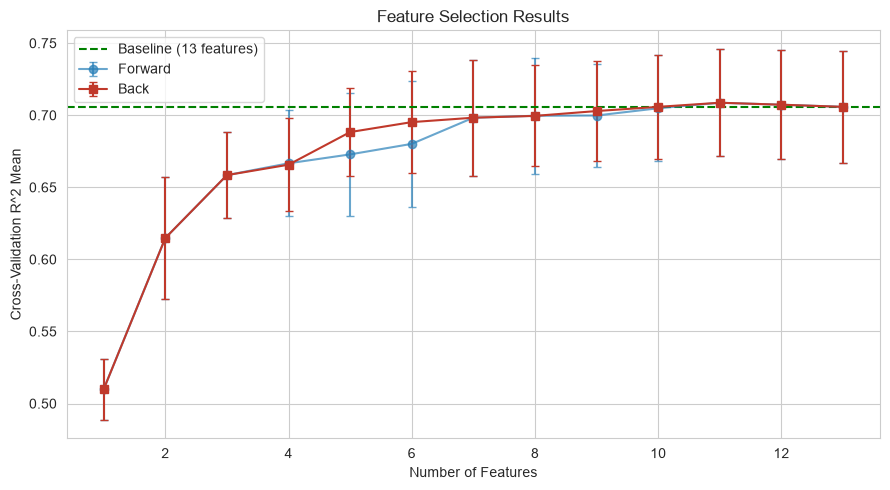

In [80]:
plt.figure(figsize=(9,5))

plt.errorbar(forward_df["n_features"], forward_df["cv_r2_mean"], yerr=forward_df["cv_r2_std"],
            marker='o', capsize=3, color="#2980b9", label="Forward", alpha=0.7)

plt.errorbar(backward_df["n_features"], backward_df["cv_r2_mean"], yerr=backward_df["cv_r2_std"],
            marker='s', capsize=3, color="#c0392b", label="Back")

plt.axhline(baseline_cv.mean(),color='g', linestyle="--", label="Baseline (13 features)")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation R^2 Mean")
plt.title("Feature Selection Results")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** the two curves overlap almost everywhere — but not
everywhere. Look closely at sizes 4, 5, 7, 8, and 9. Step 6 pulls out
exactly what's different there.

## 6. Where forward and backward actually disagree

Merge both paths on `n_features` and look at the exact feature sets and
scores side by side.

In [92]:
compare = forward_df.merge(backward_df, on="n_features", suffixes=("_forward", "_backward"))

compare.head(4)

,n_features,features,cv_r2_mean_forward,cv_r2_std_forward,feature,cv_r2_mean_backward,cv_r2_std_backward
0,1,"(LSTAT,)",0.509901,0.021127,"(LSTAT,)",0.509901,0.021127
1,2,"(RM, LSTAT)",0.614817,0.042242,"(RM, LSTAT)",0.614817,0.042242
2,3,"(RM, PTRATIO, LSTAT)",0.658450,0.029954,"(RM, PTRATIO, LSTAT)",0.658450,0.029954
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666654,0.036635,"(RM, DIS, PTRATIO, LSTAT)",0.665680,0.032342


In [ ]:
compare["same_features"] = compare.apply(
    lambda r: set(r["feature_forward"]) == set(r["feature_backward"]), axis=1
)